# Tea Leaf Disease Classification
## Task 3: Custom CNN | Task 4: Attention-Enhanced CNN (CBAM)
**Dataset:** Tea Leaf Health Dataset — 2 Classes: `Diseased Leaf`, `Healthy Leaf`

---
## 1. Imports & Setup

In [1]:
import os, time, copy, random, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from scipy.stats import ttest_rel

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla P100-PCIE-16GB


---
## 2. Hyperparameters

In [2]:
DATA_DIR    = '/kaggle/input/tea-leaf-health-dataset/Tea leaf Dataset'
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 50
LR          = 1e-3
PATIENCE    = 8        # early stopping patience (min 5 epochs enforced)
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
NUM_WORKERS = 2
NUM_CLASSES = 2
CLASS_NAMES = ['Diseased Leaf', 'Healthy Leaf']

print('Hyperparameters loaded.')

Hyperparameters loaded.


---
## 3. Data Preprocessing & Augmentation

In [3]:
# ── Transforms ─────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.85, 1.15)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataset & Split ────────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
print(f'Total samples  : {len(full_dataset)}')
print(f'Classes        : {full_dataset.classes}')
print(f'Class-to-index : {full_dataset.class_to_idx}')

total   = len(full_dataset)
n_test  = int(total * TEST_SPLIT)
n_val   = int(total * VAL_SPLIT)
n_train = total - n_val - n_test

train_ds_raw, val_ds_raw, test_ds_raw = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Re-apply eval transform to val & test (load from path)
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, _ = self.subset.dataset.samples[self.subset.indices[idx]]
        label   = self.subset.dataset.targets[self.subset.indices[idx]]
        img     = Image.open(path).convert('RGB')
        return self.transform(img), label

val_ds  = TransformSubset(val_ds_raw,  eval_transforms)
test_ds = TransformSubset(test_ds_raw, eval_transforms)

train_loader = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nTrain : {n_train} | Val : {n_val} | Test : {n_test}')

Total samples  : 747
Classes        : ['Diseased Leaf', 'Healthy Leaf']
Class-to-index : {'Diseased Leaf': 0, 'Healthy Leaf': 1}

Train : 523 | Val : 112 | Test : 112


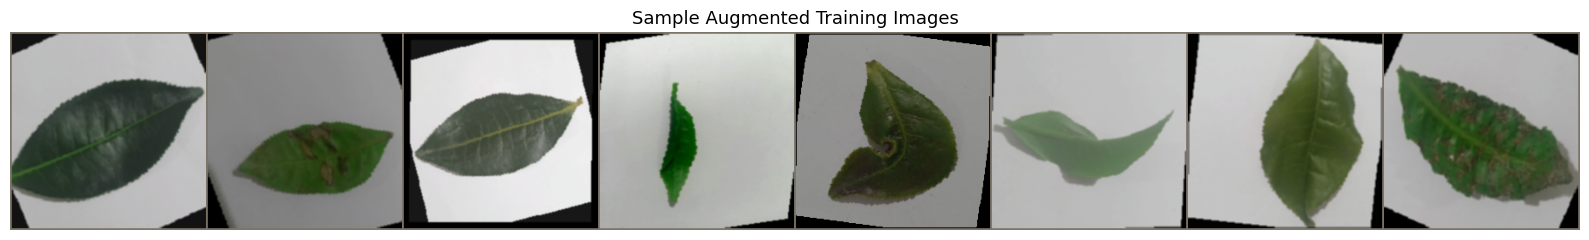

In [4]:
# ── Visualise Sample Augmented Images ─────────────────────────────────────────
def denorm(tensor):
    t = tensor.numpy().transpose((1, 2, 0))
    t = np.array([0.229, 0.224, 0.225]) * t + np.array([0.485, 0.456, 0.406])
    return np.clip(t, 0, 1)

imgs, labels = next(iter(train_loader))
grid = make_grid(imgs[:8], nrow=8)
plt.figure(figsize=(16, 3))
plt.imshow(denorm(grid))
plt.title('Sample Augmented Training Images', fontsize=13)
plt.axis('off'); plt.tight_layout(); plt.show()

---
## 4. Task 3 — Custom CNN Model

In [5]:
# ── Building Block ─────────────────────────────────────────────────────────────
class ConvBNReLU(nn.Module):
    """Conv2d -> BatchNorm2d -> ReLU"""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


# ── Custom CNN ─────────────────────────────────────────────────────────────────
class CustomCNN(nn.Module):
    """
    5-block VGG-style CNN built from scratch.
    Channels: 3 -> 32 -> 64 -> 128 -> 256 -> 512
    Classifier: FC(1024) -> FC(512) -> FC(num_classes)
    """
    def __init__(self, num_classes=2, drop_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — 224x224 -> 112x112
            ConvBNReLU(3,   32), ConvBNReLU(32,  32),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.10),
            # Block 2 — 112x112 -> 56x56
            ConvBNReLU(32,  64), ConvBNReLU(64,  64),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.10),
            # Block 3 — 56x56 -> 28x28
            ConvBNReLU(64,  128), ConvBNReLU(128, 128), ConvBNReLU(128, 128),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.20),
            # Block 4 — 28x28 -> 14x14
            ConvBNReLU(128, 256), ConvBNReLU(256, 256), ConvBNReLU(256, 256),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.20),
            # Block 5 — 14x14 -> 7x7
            ConvBNReLU(256, 512), ConvBNReLU(512, 512), ConvBNReLU(512, 512),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.30),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))   # -> 512x1x1
        self.classifier = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(drop_p),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.ReLU(inplace=True), nn.Dropout(drop_p * 0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.gap(self.features(x))
        return self.classifier(x.view(x.size(0), -1))


custom_model = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)
tp = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)
print(f'CustomCNN trainable parameters: {tp:,}')

CustomCNN trainable parameters: 8,866,786


In [6]:
# ── Training Utilities ─────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 num_epochs, patience, device, ckpt_name):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss  = float('inf')
    best_wts       = copy.deepcopy(model.state_dict())
    no_improve     = 0
    t0             = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f'[{epoch:02d}/{num_epochs}]  '
              f'Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
              f'Val  loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(model.state_dict(), ckpt_name)
        else:
            no_improve += 1
            if no_improve >= patience and epoch >= 5:
                print(f'\n⏹  Early stopping triggered at epoch {epoch}.')
                break

    duration = time.time() - t0
    model.load_state_dict(best_wts)
    print(f'\nBest Val Loss : {best_val_loss:.4f}  |  Training Time : {duration:.1f}s ({duration/60:.2f} min)')
    return model, history, duration

In [7]:
# ── Train Custom CNN ───────────────────────────────────────────────────────────
criterion_cnn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_cnn = optim.Adam(custom_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=NUM_EPOCHS, eta_min=1e-6)

print('=' * 70)
print('  TASK 3 — Training Custom CNN')
print('=' * 70)

custom_model, cnn_history, cnn_train_time = run_training(
    custom_model, train_loader, val_loader,
    criterion_cnn, optimizer_cnn, scheduler_cnn,
    NUM_EPOCHS, PATIENCE, DEVICE, 'best_custom_cnn.pth'
)

  TASK 3 — Training Custom CNN
[01/50]  Train  loss=0.7177  acc=0.6252  |  Val  loss=0.9894  acc=0.5268  |  lr=9.99e-04
[02/50]  Train  loss=0.5950  acc=0.7342  |  Val  loss=0.5367  acc=0.7500  |  lr=9.96e-04
[03/50]  Train  loss=0.6088  acc=0.7304  |  Val  loss=0.5717  acc=0.7143  |  lr=9.91e-04
[04/50]  Train  loss=0.5867  acc=0.7457  |  Val  loss=0.5356  acc=0.7768  |  lr=9.84e-04
[05/50]  Train  loss=0.6059  acc=0.7266  |  Val  loss=0.6291  acc=0.6518  |  lr=9.76e-04
[06/50]  Train  loss=0.6008  acc=0.7419  |  Val  loss=0.5565  acc=0.7679  |  lr=9.65e-04
[07/50]  Train  loss=0.5390  acc=0.8031  |  Val  loss=0.6363  acc=0.7232  |  lr=9.52e-04
[08/50]  Train  loss=0.5435  acc=0.7667  |  Val  loss=0.4992  acc=0.7946  |  lr=9.38e-04
[09/50]  Train  loss=0.5301  acc=0.7859  |  Val  loss=0.4403  acc=0.8304  |  lr=9.22e-04
[10/50]  Train  loss=0.5138  acc=0.8107  |  Val  loss=0.4390  acc=0.8393  |  lr=9.05e-04
[11/50]  Train  loss=0.4911  acc=0.8145  |  Val  loss=0.4525  acc=0.8125  |  lr

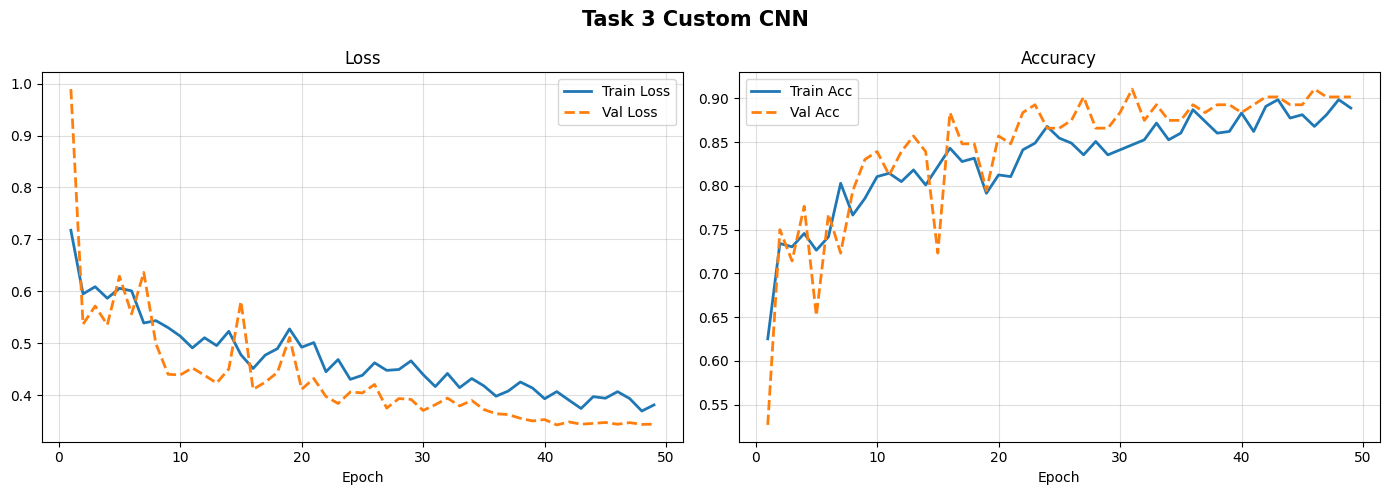

In [8]:
# ── Plot Training Curves — Custom CNN ─────────────────────────────────────────
def plot_history(history, title):
    n = len(history['train_loss'])
    x = range(1, n + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(x, history['train_loss'], lw=2, label='Train Loss')
    axes[0].plot(x, history['val_loss'],   lw=2, ls='--', label='Val Loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.4)
    axes[1].plot(x, history['train_acc'], lw=2, label='Train Acc')
    axes[1].plot(x, history['val_acc'],   lw=2, ls='--', label='Val Acc')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)
    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(title.replace(' ', '_').lower() + '_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(cnn_history, 'Task 3 Custom CNN')

In [9]:
# ── Evaluation Helper ──────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_model(model, loader, device, class_names, label):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    t0 = time.time()
    for imgs, labels in loader:
        imgs = imgs.to(device)
        probs = F.softmax(model(imgs), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(labels.numpy())
    test_time = time.time() - t0

    probs  = np.concatenate(all_probs)
    preds  = np.array(all_preds)
    labels = np.array(all_labels)

    acc       = accuracy_score(labels, preds)
    prec      = precision_score(labels, preds, average='weighted', zero_division=0)
    rec       = recall_score(labels, preds, average='weighted', zero_division=0)
    f1        = f1_score(labels, preds, average='weighted', zero_division=0)
    auc       = roc_auc_score(labels, probs[:, 1])
    cm        = confusion_matrix(labels, preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)

    print(f'\n{"="*60}')
    print(f'  {label} — Test Set Results')
    print(f'{"="*60}')
    print(f'  Overall Accuracy  : {acc:.4f}')
    for i, c in enumerate(class_names):
        print(f'  Class Acc [{c:13s}] : {class_acc[i]:.4f}')
    print(f'  Precision (w)     : {prec:.4f}')
    print(f'  Recall (w)        : {rec:.4f}')
    print(f'  F1-Score (w)      : {f1:.4f}')
    print(f'  AUC-ROC           : {auc:.4f}')
    print(f'  Test Time         : {test_time:.4f}s')
    print('\n  Classification Report:')
    print(classification_report(labels, preds, target_names=class_names, digits=4))

    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auc=auc,
                cm=cm, class_acc=class_acc, probs=probs,
                preds=preds, labels=labels, test_time=test_time)


cnn_results = evaluate_model(custom_model, test_loader, DEVICE, CLASS_NAMES, 'Custom CNN')
print(f'  Training Time     : {cnn_train_time:.2f}s')


  Custom CNN — Test Set Results
  Overall Accuracy  : 0.9018
  Class Acc [Diseased Leaf] : 0.8852
  Class Acc [Healthy Leaf ] : 0.9216
  Precision (w)     : 0.9034
  Recall (w)        : 0.9018
  F1-Score (w)      : 0.9020
  AUC-ROC           : 0.9576
  Test Time         : 13.4310s

  Classification Report:
               precision    recall  f1-score   support

Diseased Leaf     0.9310    0.8852    0.9076        61
 Healthy Leaf     0.8704    0.9216    0.8952        51

     accuracy                         0.9018       112
    macro avg     0.9007    0.9034    0.9014       112
 weighted avg     0.9034    0.9018    0.9020       112

  Training Time     : 3559.16s


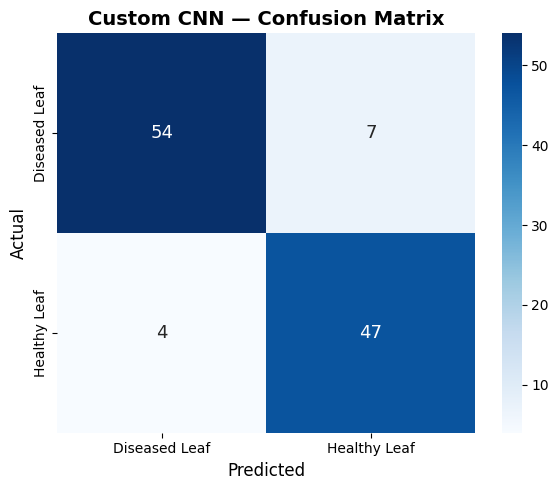

In [10]:
# ── Confusion Matrix — Custom CNN ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cnn_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            annot_kws={'size': 13})
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Custom CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

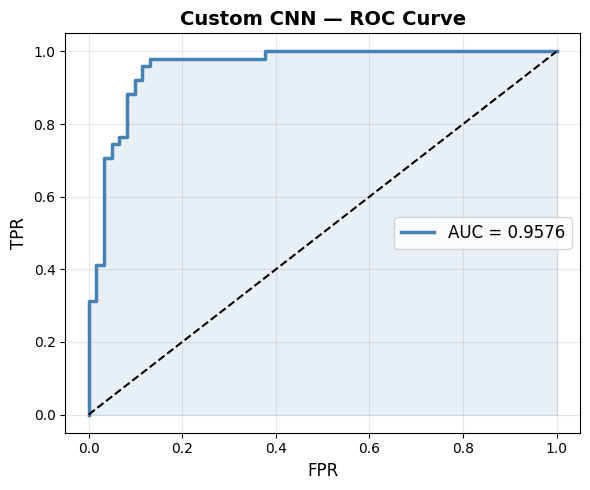

In [11]:
# ── ROC Curve — Custom CNN ─────────────────────────────────────────────────────
fpr_cnn, tpr_cnn, _ = roc_curve(cnn_results['labels'], cnn_results['probs'][:, 1])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_cnn, tpr_cnn, color='steelblue', lw=2.5,
        label=f'AUC = {cnn_results["auc"]:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.5)
ax.fill_between(fpr_cnn, tpr_cnn, alpha=0.12, color='steelblue')
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Custom CNN — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Task 4 — Attention-Enhanced CNN (CBAM)

In [12]:
# ── CBAM: Channel Attention ────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c = x.size(0), x.size(1)
        avg = self.mlp(self.avg_pool(x).view(b, c))
        mx  = self.mlp(self.max_pool(x).view(b, c))
        return self.sigmoid(avg + mx).view(b, c, 1, 1) * x


# ── CBAM: Spatial Attention ────────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


# ── Full CBAM Module ───────────────────────────────────────────────────────────
class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., 2018)"""
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.spatial(self.channel(x))


print('CBAM module defined.')

CBAM module defined.


In [13]:
# ── Attention-Enhanced CNN ─────────────────────────────────────────────────────
class AttentionCNN(nn.Module):
    """
    Same 5-block CNN as CustomCNN, but with a CBAM module
    inserted after each convolutional block (before pooling).
    """
    def __init__(self, num_classes=2, drop_p=0.5):
        super().__init__()

        def make_block(in_ch, out_ch, n_conv):
            layers = [ConvBNReLU(in_ch, out_ch)]
            for _ in range(n_conv - 1):
                layers.append(ConvBNReLU(out_ch, out_ch))
            return nn.Sequential(*layers)

        self.block1 = make_block(3,   32,  2);  self.cbam1 = CBAM(32);  self.pool1 = nn.Sequential(nn.MaxPool2d(2,2), nn.Dropout2d(0.10))
        self.block2 = make_block(32,  64,  2);  self.cbam2 = CBAM(64);  self.pool2 = nn.Sequential(nn.MaxPool2d(2,2), nn.Dropout2d(0.10))
        self.block3 = make_block(64,  128, 3);  self.cbam3 = CBAM(128); self.pool3 = nn.Sequential(nn.MaxPool2d(2,2), nn.Dropout2d(0.20))
        self.block4 = make_block(128, 256, 3);  self.cbam4 = CBAM(256); self.pool4 = nn.Sequential(nn.MaxPool2d(2,2), nn.Dropout2d(0.20))
        self.block5 = make_block(256, 512, 3);  self.cbam5 = CBAM(512); self.pool5 = nn.Sequential(nn.MaxPool2d(2,2), nn.Dropout2d(0.30))

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(drop_p),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.ReLU(inplace=True), nn.Dropout(drop_p * 0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.pool1(self.cbam1(self.block1(x)))
        x = self.pool2(self.cbam2(self.block2(x)))
        x = self.pool3(self.cbam3(self.block3(x)))
        x = self.pool4(self.cbam4(self.block4(x)))
        x = self.pool5(self.cbam5(self.block5(x)))
        x = self.gap(x).view(x.size(0), -1)
        return self.classifier(x)


attn_model = AttentionCNN(num_classes=NUM_CLASSES).to(DEVICE)
tp = sum(p.numel() for p in attn_model.parameters() if p.requires_grad)
print(f'AttentionCNN trainable parameters: {tp:,}')

AttentionCNN trainable parameters: 8,911,820


In [14]:
# ── Train Attention CNN ────────────────────────────────────────────────────────
criterion_att = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_att = optim.Adam(attn_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler_att = optim.lr_scheduler.CosineAnnealingLR(optimizer_att, T_max=NUM_EPOCHS, eta_min=1e-6)

print('=' * 70)
print('  TASK 4 — Training Attention-Enhanced CNN (CBAM)')
print('=' * 70)

attn_model, att_history, att_train_time = run_training(
    attn_model, train_loader, val_loader,
    criterion_att, optimizer_att, scheduler_att,
    NUM_EPOCHS, PATIENCE, DEVICE, 'best_attention_cnn.pth'
)

  TASK 4 — Training Attention-Enhanced CNN (CBAM)
[01/50]  Train  loss=0.7678  acc=0.5163  |  Val  loss=0.6890  acc=0.5625  |  lr=9.99e-04
[02/50]  Train  loss=0.6944  acc=0.6386  |  Val  loss=0.6951  acc=0.5893  |  lr=9.96e-04
[03/50]  Train  loss=0.6282  acc=0.6922  |  Val  loss=0.6488  acc=0.6875  |  lr=9.91e-04
[04/50]  Train  loss=0.6062  acc=0.7189  |  Val  loss=0.6058  acc=0.7411  |  lr=9.84e-04
[05/50]  Train  loss=0.5557  acc=0.7629  |  Val  loss=0.6059  acc=0.6786  |  lr=9.76e-04
[06/50]  Train  loss=0.5617  acc=0.7572  |  Val  loss=0.5269  acc=0.7946  |  lr=9.65e-04
[07/50]  Train  loss=0.5630  acc=0.7610  |  Val  loss=0.5365  acc=0.8304  |  lr=9.52e-04
[08/50]  Train  loss=0.5168  acc=0.7935  |  Val  loss=0.4947  acc=0.7857  |  lr=9.38e-04
[09/50]  Train  loss=0.5013  acc=0.8031  |  Val  loss=0.4980  acc=0.8036  |  lr=9.22e-04
[10/50]  Train  loss=0.5132  acc=0.8145  |  Val  loss=0.5566  acc=0.7411  |  lr=9.05e-04
[11/50]  Train  loss=0.4949  acc=0.8145  |  Val  loss=0.4684

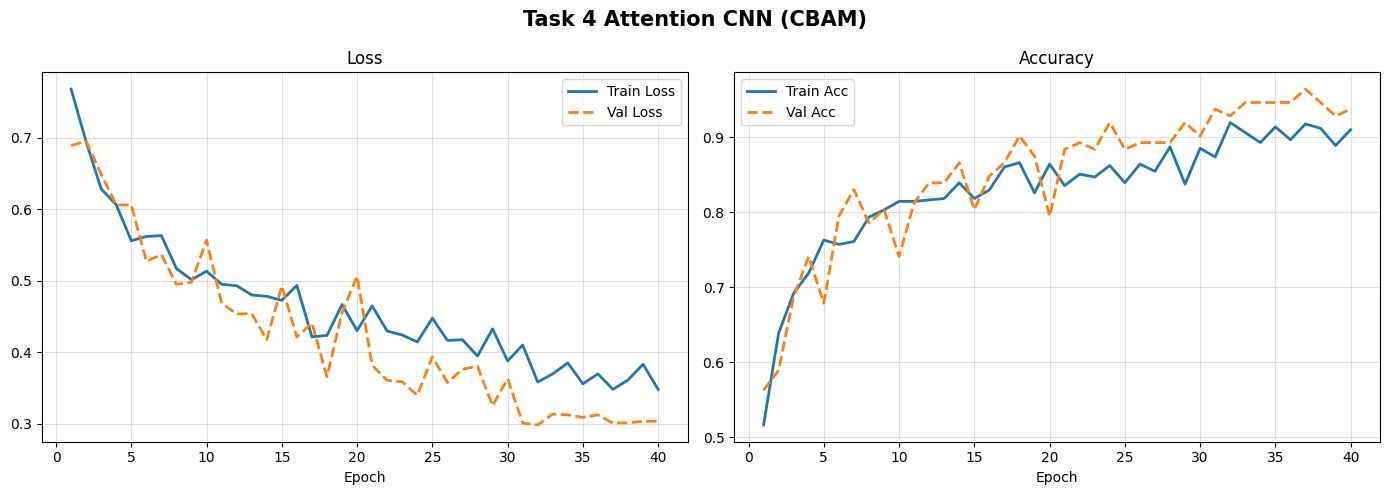

In [15]:
plot_history(att_history, 'Task 4 Attention CNN (CBAM)')

In [16]:
att_results = evaluate_model(attn_model, test_loader, DEVICE, CLASS_NAMES, 'Attention CNN (CBAM)')
print(f'  Training Time     : {att_train_time:.2f}s')


  Attention CNN (CBAM) — Test Set Results
  Overall Accuracy  : 0.9554
  Class Acc [Diseased Leaf] : 0.9344
  Class Acc [Healthy Leaf ] : 0.9804
  Precision (w)     : 0.9569
  Recall (w)        : 0.9554
  F1-Score (w)      : 0.9554
  AUC-ROC           : 0.9765
  Test Time         : 13.5541s

  Classification Report:
               precision    recall  f1-score   support

Diseased Leaf     0.9828    0.9344    0.9580        61
 Healthy Leaf     0.9259    0.9804    0.9524        51

     accuracy                         0.9554       112
    macro avg     0.9543    0.9574    0.9552       112
 weighted avg     0.9569    0.9554    0.9554       112

  Training Time     : 2930.88s


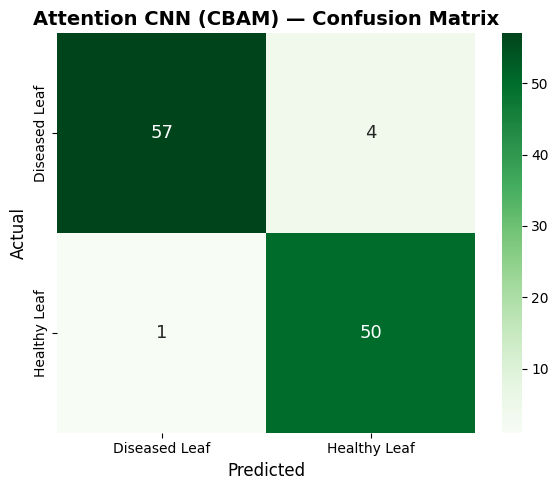

In [17]:
# ── Confusion Matrix — Attention CNN ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(att_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            annot_kws={'size': 13})
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Attention CNN (CBAM) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

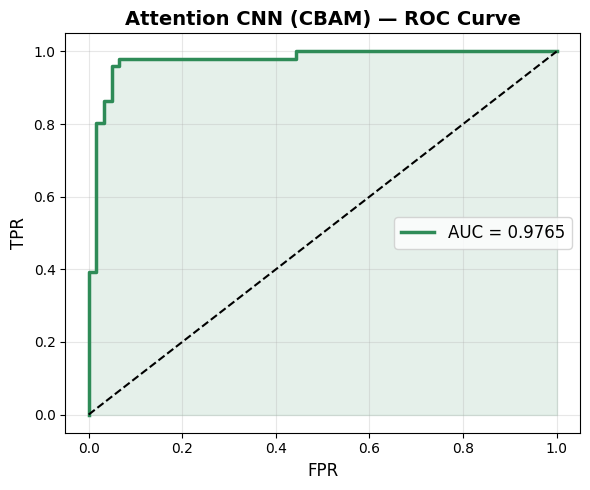

In [18]:
# ── ROC Curve — Attention CNN ──────────────────────────────────────────────────
fpr_att, tpr_att, _ = roc_curve(att_results['labels'], att_results['probs'][:, 1])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_att, tpr_att, color='seagreen', lw=2.5,
        label=f'AUC = {att_results["auc"]:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.5)
ax.fill_between(fpr_att, tpr_att, alpha=0.12, color='seagreen')
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Attention CNN (CBAM) — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('attn_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comparison: Task 3 vs Task 4

                   Metric Custom CNN Attention CNN
                 Accuracy     0.9018        0.9554
            Precision (w)     0.9034        0.9569
               Recall (w)     0.9018        0.9554
             F1-Score (w)     0.9020        0.9554
                  AUC-ROC     0.9576        0.9765
Class Acc [Diseased Leaf]     0.8852        0.9344
 Class Acc [Healthy Leaf]     0.9216        0.9804
           Train Time (s)    3559.16       2930.88
            Test Time (s)    13.4310       13.5541


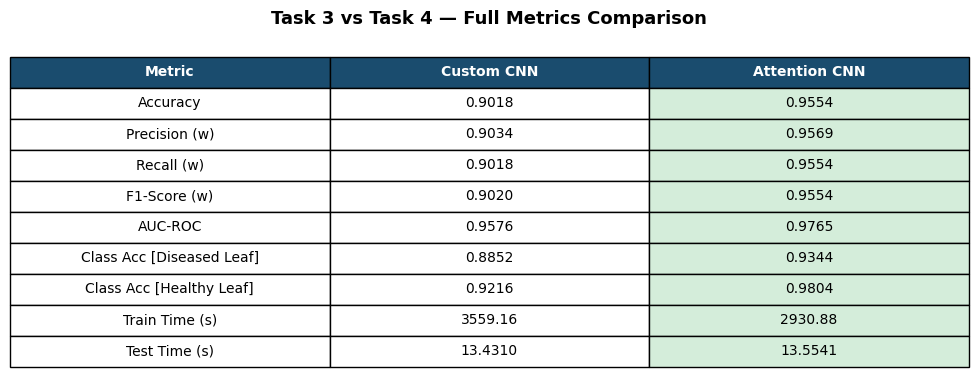

In [19]:
# ── Metrics Comparison Table ───────────────────────────────────────────────────
rows = {
    'Metric':          ['Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)', 'AUC-ROC',
                        f'Class Acc [{CLASS_NAMES[0]}]', f'Class Acc [{CLASS_NAMES[1]}]',
                        'Train Time (s)', 'Test Time (s)'],
    'Custom CNN':      [f"{cnn_results['acc']:.4f}",
                        f"{cnn_results['prec']:.4f}",
                        f"{cnn_results['rec']:.4f}",
                        f"{cnn_results['f1']:.4f}",
                        f"{cnn_results['auc']:.4f}",
                        f"{cnn_results['class_acc'][0]:.4f}",
                        f"{cnn_results['class_acc'][1]:.4f}",
                        f"{cnn_train_time:.2f}",
                        f"{cnn_results['test_time']:.4f}"],
    'Attention CNN':   [f"{att_results['acc']:.4f}",
                        f"{att_results['prec']:.4f}",
                        f"{att_results['rec']:.4f}",
                        f"{att_results['f1']:.4f}",
                        f"{att_results['auc']:.4f}",
                        f"{att_results['class_acc'][0]:.4f}",
                        f"{att_results['class_acc'][1]:.4f}",
                        f"{att_train_time:.2f}",
                        f"{att_results['test_time']:.4f}"],
}
df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Styled plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.3, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a4c6e'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 2:
        cell.set_facecolor('#d4edda')
ax.set_title('Task 3 vs Task 4 — Full Metrics Comparison', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

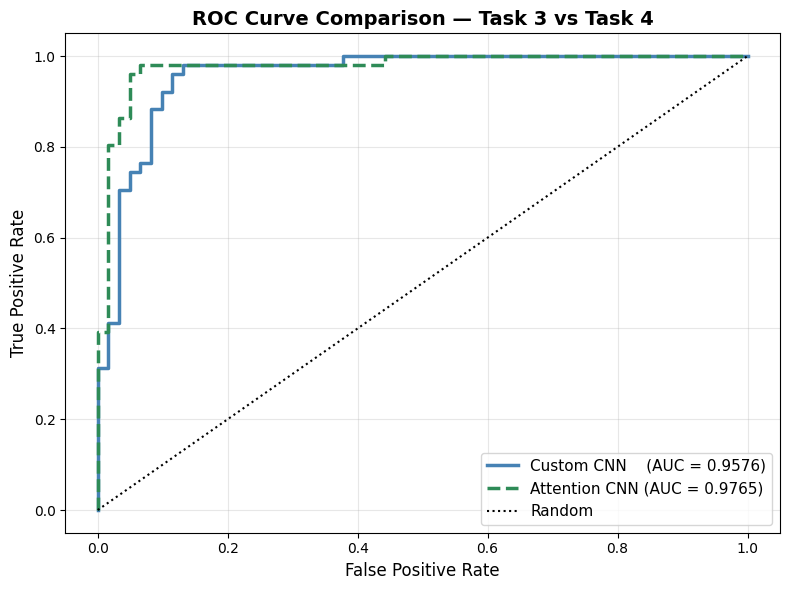

In [20]:
# ── Side-by-Side ROC ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_cnn, tpr_cnn, color='steelblue', lw=2.5,
        label=f'Custom CNN    (AUC = {cnn_results["auc"]:.4f})')
ax.plot(fpr_att, tpr_att, color='seagreen',  lw=2.5, ls='--',
        label=f'Attention CNN (AUC = {att_results["auc"]:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve Comparison — Task 3 vs Task 4', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

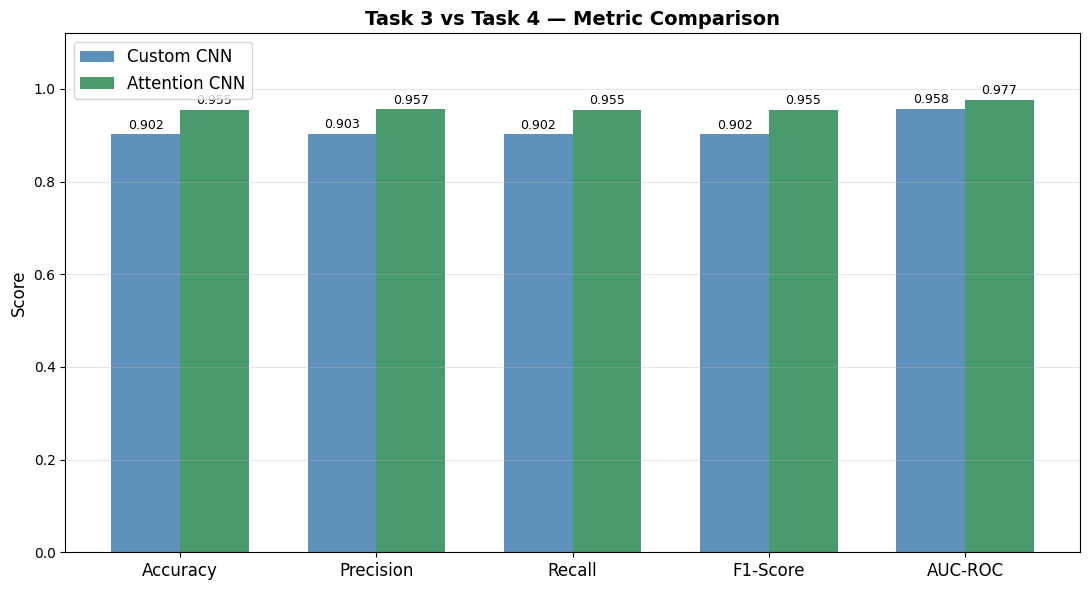

In [21]:
# ── Bar Chart Comparison ───────────────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
cnn_vals     = [cnn_results['acc'], cnn_results['prec'], cnn_results['rec'],
                cnn_results['f1'], cnn_results['auc']]
att_vals     = [att_results['acc'], att_results['prec'], att_results['rec'],
                att_results['f1'], att_results['auc']]

x, w = np.arange(len(metric_names)), 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, cnn_vals, w, label='Custom CNN',    color='steelblue', alpha=0.87)
b2 = ax.bar(x + w/2, att_vals, w, label='Attention CNN', color='seagreen',  alpha=0.87)

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Task 3 vs Task 4 — Metric Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Paired t-test ──────────────────────────────────────────────────────────────
print('=' * 60)
print('  PAIRED t-TEST: Custom CNN vs Attention CNN')
print('=' * 60)

shared_labels = cnn_results['labels']           # same test set
cnn_correct   = (cnn_results['preds'] == shared_labels).astype(float)
att_correct   = (att_results['preds'] == shared_labels).astype(float)

t_stat, p_val = ttest_rel(att_correct, cnn_correct)

print(f'  Custom CNN  mean correct : {cnn_correct.mean():.4f}')
print(f'  Attention CNN mean correct: {att_correct.mean():.4f}')
print(f'  t-statistic              : {t_stat:.4f}')
print(f'  p-value                  : {p_val:.6f}')
print()
if p_val < 0.05:
    print('  ✅ Statistically SIGNIFICANT difference (p < 0.05).')
    print('     The Attention CNN performs significantly differently.')
else:
    print('  ⚠️  No statistically significant difference (p ≥ 0.05).')
    print('     Both models perform similarly on this dataset.')
print('=' * 60)

  PAIRED t-TEST: Custom CNN vs Attention CNN
  Custom CNN  mean correct : 0.9018
  Attention CNN mean correct: 0.9554
  t-statistic              : 2.5066
  p-value                  : 0.013639

  ✅ Statistically SIGNIFICANT difference (p < 0.05).
     The Attention CNN performs significantly differently.


In [23]:
print('\n✅ All tasks complete! Generated files:')
for f in sorted(os.listdir('.')):
    if f.endswith(('.png', '.pth')):
        print(f'   {f}')


✅ All tasks complete! Generated files:
   attn_confusion_matrix.png
   attn_roc.png
   bar_comparison.png
   best_attention_cnn.pth
   best_custom_cnn.pth
   cnn_confusion_matrix.png
   cnn_roc.png
   comparison_table.png
   roc_comparison.png
   task_3_custom_cnn_curves.png
   task_4_attention_cnn_(cbam)_curves.png
